# Create a dataset for EVASPA with landsat8 data 
* On a specific S2 tile ID
* On S2 tiles corresponding to a specific ROI

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append("../src")

In [3]:
import os
import geopandas as gpd
from tqdm import tqdm
from sensorsio import mgrs

In [4]:
from etdataset.api import create_dataset
from etdataset.plot import plot_images
from etdataset.writer import write_dataset, export_matlab
from etdataset.utils import get_bbox_from_mgrs_tile, get_bbox_from_roi

### Inputs 
* Landsat product path
* S2 tile id or ROI path

In [5]:
# Path to Landsat product
data_path = os.environ["DATA_PATH"]
ls8_path = os.path.join(
    data_path, "Landsat8", "LC09_L2SP_205050_20230327_20230329_02_T1"
)

In [6]:
# S2 tile Id or ROI shapefile
s2_tile_id = "28PCA"
roi_path = os.path.join(data_path, "zones", "Zone_Senegal_Centre.shp")

In [7]:
# Output directory for results
output_dir = "out"
os.makedirs(output_dir, exist_ok=True)

### Create dataset from Landsat8 product for a specific S2 tile ID

In [8]:
# To take or not into account mask, use option use_mask
ls8 = create_dataset(vis_path=ls8_path, tile_id=s2_tile_id,use_mask=True)

(<Figure size 1500x1500 with 11 Axes>,
 array([[<Axes: title={'center': 'RGB'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'LST'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Emissivity'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Albedo'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'NDVI'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'LAI'}, xlabel='x', ylabel='y'>]],
       dtype=object))

/home/sarrazine/pyenvs/etdataset/lib/python3.10/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


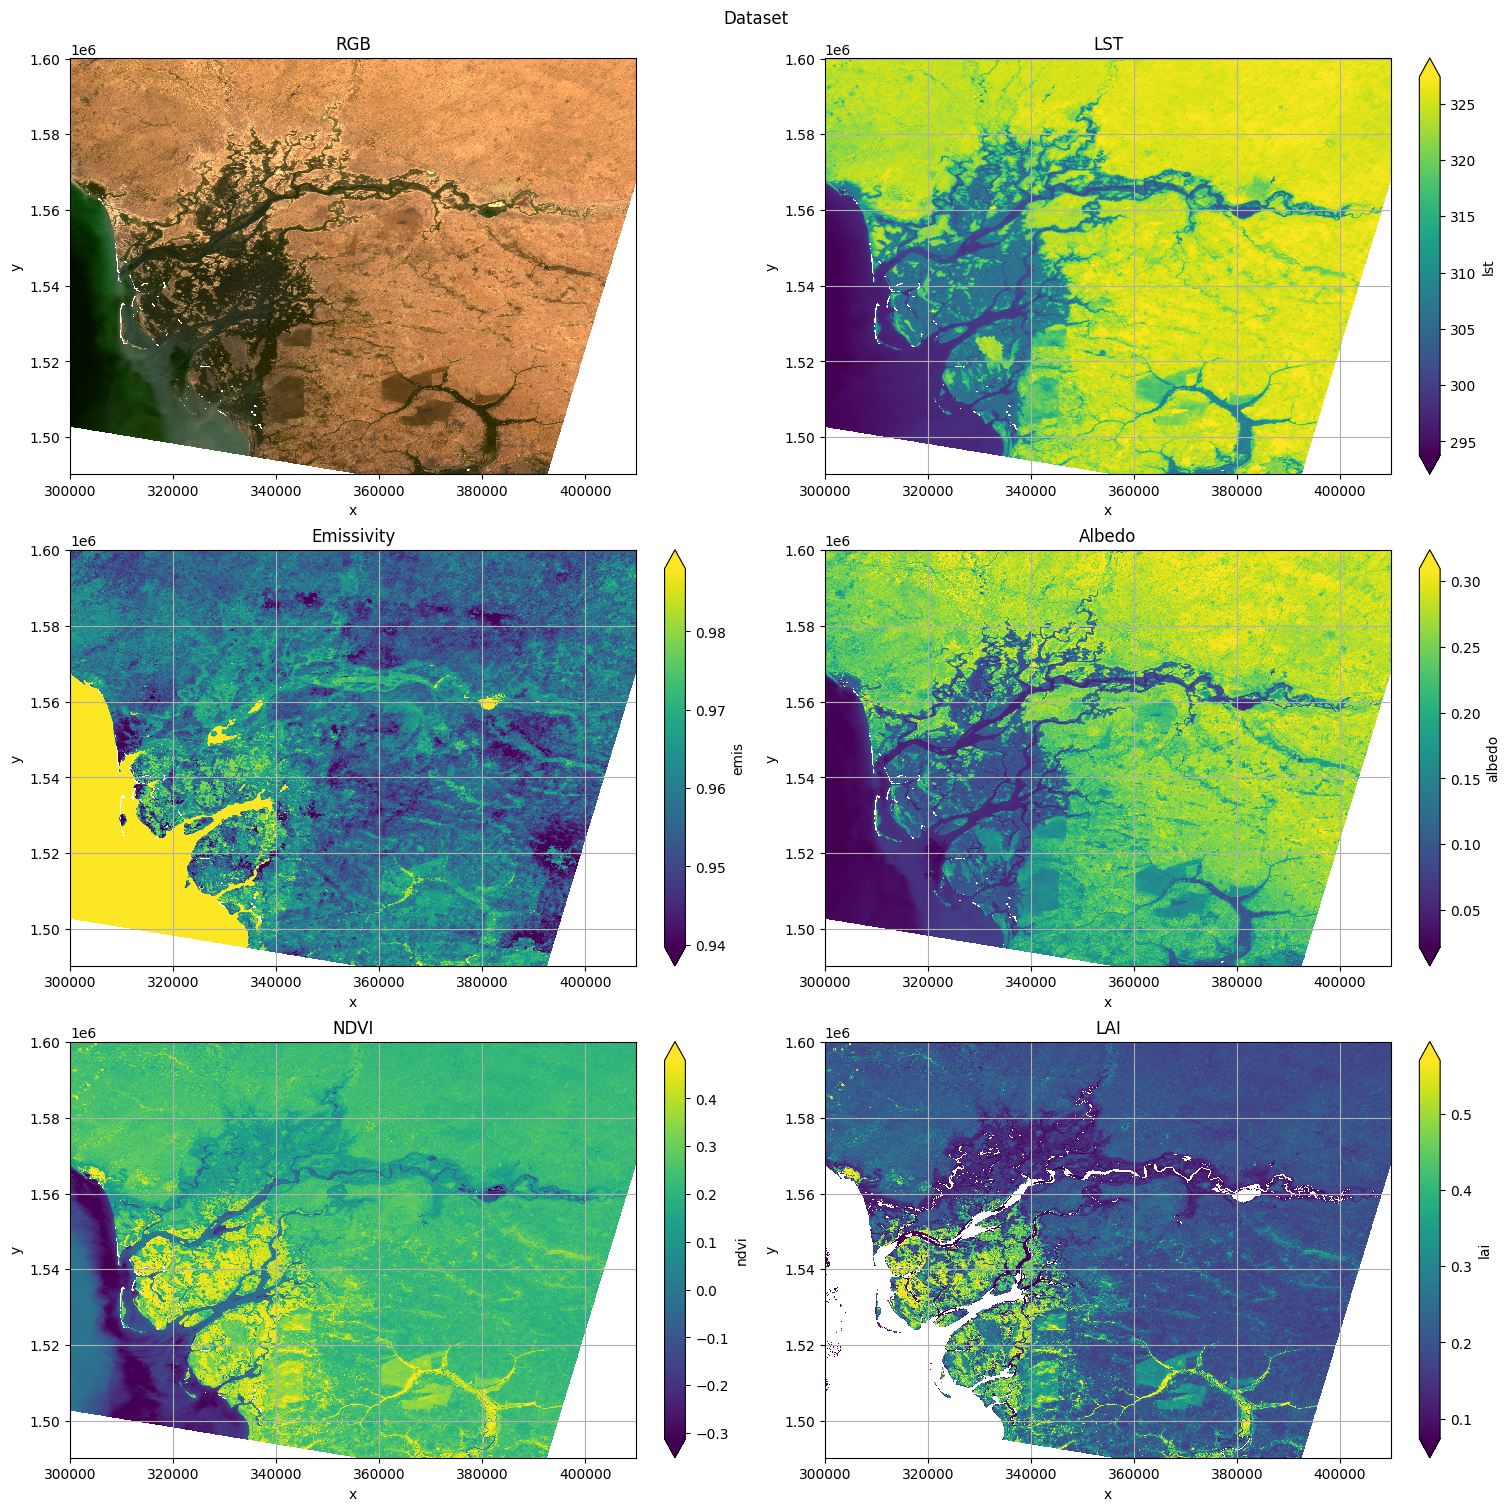

In [9]:
plot_images(ls8)

### Create datasets from Landsat8 product for ROI

The Landsat product is tiled on MRGS tiles. Only tiles with more than 20% overlap are processed.

In [10]:
roi_bbox, roi_crs = get_bbox_from_roi(roi_path)

In [11]:
tile_ids = mgrs.get_mgrs_tiles_from_roi(roi_bbox, roi_crs)
tile_ids

,Name,overlap_geometry,geometry,overlap_percentage
0,28PBA,"POLYGON ((-16.76482 14.46621, -16.75975 13.800...","POLYGON ((-17.78282 14.45638, -16.76482 14.466...",22.271238
1,28PBB,"POLYGON ((-16.76412 14.37783, -17.10000 14.374...","POLYGON ((-17.79446 15.35961, -16.77221 15.370...",20.551890
2,28PCA,"POLYGON ((-15.90000 14.47098, -15.90000 13.800...","POLYGON ((-16.85552 14.46551, -15.83696 14.471...",63.120620
3,28PCB,"POLYGON ((-16.85479 14.37713, -16.86012 15.000...","POLYGON ((-16.86329 15.36934, -15.84047 15.375...",58.627789
4,28PDA,"POLYGON ((-15.90000 14.47105, -15.90000 13.800...","POLYGON ((-15.92826 14.47100, -14.90943 14.472...",1.789794
5,28PDB,"POLYGON ((-15.92790 14.38258, -15.93054 15.000...","POLYGON ((-15.93215 15.37519, -14.90905 15.377...",1.780280


Keep tiles ID with more than 20% of overlap

In [12]:
tile_ids = tile_ids[tile_ids["overlap_percentage"] >= 20.0]

In [13]:
tile_ids

,Name,overlap_geometry,geometry,overlap_percentage
0,28PBA,"POLYGON ((-16.76482 14.46621, -16.75975 13.800...","POLYGON ((-17.78282 14.45638, -16.76482 14.466...",22.271238
1,28PBB,"POLYGON ((-16.76412 14.37783, -17.10000 14.374...","POLYGON ((-17.79446 15.35961, -16.77221 15.370...",20.551890
2,28PCA,"POLYGON ((-15.90000 14.47098, -15.90000 13.800...","POLYGON ((-16.85552 14.46551, -15.83696 14.471...",63.120620
3,28PCB,"POLYGON ((-16.85479 14.37713, -16.86012 15.000...","POLYGON ((-16.86329 15.36934, -15.84047 15.375...",58.627789


Create the datasets 

In [14]:
datasets = []
for tile_id in tqdm(tile_ids.Name.values):
    ls8 = create_dataset(vis_path=ls8_path, tile_id=tile_id)
    datasets.append(ls8)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:26<00:00,  6.63s/it]


Write results

In [15]:
for ds in tqdm(datasets):
    write_dataset(ds, directory=output_dir)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  9.58it/s]
